
# Notebook 1B — Biological validation of the selected dimer interface

## Purpose

This notebook is designed to run **after Notebook 1** and to test whether the selected chain pair **B–D** is supported as the most plausible biological interface.

It does **not** force B–D to be the answer. It:

1. loads the crystallographic asymmetric unit;
2. downloads or loads the annotated biological assembly;
3. compares every protein chain pair;
4. calculates geometric and physicochemical interface descriptors;
5. checks whether B–D is reproduced in the biological assembly;
6. optionally retrieves PDBePISA interface data;
7. generates a transparent evidence table and a final validation report.

## Interpretation

The final verdict is one of:

- **SUPPORTED** — B–D is consistently supported by the available structural evidence;
- **PLAUSIBLE BUT NOT UNIQUE** — B–D is plausible, but another interface is comparable;
- **NOT SUPPORTED** — another interface is better supported or B–D is absent;
- **INCONCLUSIVE** — insufficient or conflicting evidence.

This is a **computational structural validation**, not a substitute for experimental validation.


In [1]:

# Install only the packages that are missing.
# Restarting the kernel is normally not required.

import sys
import subprocess
import importlib.util

required = {
    "Bio": "biopython",
    "pandas": "pandas",
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "requests": "requests",
}

for module_name, package_name in required.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("Dependencies ready.")


Dependencies ready.


## 1. Configuration

In [2]:

from pathlib import Path
import os
import re
import json
import math
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from Bio.PDB import (
    PDBParser, MMCIFParser, MMCIFIO, PDBIO,
    NeighborSearch, Selection, ShrakeRupley
)
from Bio.PDB.Polypeptide import is_aa

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# USER CONFIGURATION
# ------------------------------------------------------------------

# Values are recovered from Notebook 1 when matching variables exist.
# Otherwise the PEARL/EGFR defaults are used.
PDB_ID = str(
    globals().get("PDB_ID",
    globals().get("pdb_id",
    globals().get("PDB_CODE", "3NJP")))
).upper()

TARGET_CHAIN_1 = str(globals().get("TARGET_CHAIN_1", "B"))
TARGET_CHAIN_2 = str(globals().get("TARGET_CHAIN_2", "D"))
TARGET_PAIR = tuple(sorted((TARGET_CHAIN_1, TARGET_CHAIN_2)))

# Contact cutoffs in Å
HEAVY_ATOM_CONTACT_CUTOFF = 4.5
CA_CONTACT_CUTOFF = 8.0
HBOND_DISTANCE_CUTOFF = 3.5
SALT_BRIDGE_CUTOFF = 4.0

# Interface is ignored if it has fewer contacts than this.
MIN_HEAVY_ATOM_CONTACTS = 5

# Output directory
OUTPUT_DIR = Path(globals().get("OUTPUT_DIR", "outputs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional explicit input file. Leave as None to auto-detect/download.
INPUT_STRUCTURE_PATH = globals().get("INPUT_STRUCTURE_PATH", None)

# Biological assembly to analyse.
ASSEMBLY_ID = str(globals().get("ASSEMBLY_ID", "1"))

print("PDB ID:", PDB_ID)
print("Target pair:", TARGET_PAIR)
print("Assembly ID:", ASSEMBLY_ID)
print("Output directory:", OUTPUT_DIR.resolve())


/Users/robertobruzzese/Desktop/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


PDB ID: 3NJP
Target pair: ('B', 'D')
Assembly ID: 1
Output directory: /Users/robertobruzzese/Desktop/venv/outputs


## 2. Locate or download the asymmetric unit and biological assembly

In [3]:

def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists() and p.is_file():
            return p
    return None


def download_file(url, destination, timeout=60):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    destination.write_bytes(response.content)
    return destination


def locate_asymmetric_unit(pdb_id, explicit_path=None):
    candidates = []
    if explicit_path:
        candidates.append(explicit_path)

    candidates.extend([
        f"{pdb_id}.cif", f"{pdb_id.lower()}.cif",
        f"{pdb_id}.pdb", f"{pdb_id.lower()}.pdb",
        OUTPUT_DIR / f"{pdb_id}.cif",
        OUTPUT_DIR / f"{pdb_id}.pdb",
        Path("data") / f"{pdb_id}.cif",
        Path("data") / f"{pdb_id}.pdb",
        Path("inputs") / f"{pdb_id}.cif",
        Path("inputs") / f"{pdb_id}.pdb",
    ])

    found = first_existing(candidates)
    if found:
        return found

    destination = OUTPUT_DIR / f"{pdb_id}.cif"
    url = f"https://files.rcsb.org/download/{pdb_id}.cif"
    print("Local asymmetric unit not found; downloading:", url)
    return download_file(url, destination)


def locate_biological_assembly(pdb_id, assembly_id="1"):
    candidates = [
        f"{pdb_id}-assembly{assembly_id}.cif",
        f"{pdb_id.lower()}-assembly{assembly_id}.cif",
        OUTPUT_DIR / f"{pdb_id}-assembly{assembly_id}.cif",
        Path("data") / f"{pdb_id}-assembly{assembly_id}.cif",
        Path("inputs") / f"{pdb_id}-assembly{assembly_id}.cif",
    ]

    found = first_existing(candidates)
    if found:
        return found

    destination = OUTPUT_DIR / f"{pdb_id}-assembly{assembly_id}.cif"
    url = f"https://files.rcsb.org/download/{pdb_id}-assembly{assembly_id}.cif"
    print("Local biological assembly not found; downloading:", url)
    try:
        return download_file(url, destination)
    except Exception:
        # Official RCSB also exposes assembly files through /view/
        url = f"https://files.rcsb.org/view/{pdb_id}-assembly{assembly_id}.cif"
        print("Retrying:", url)
        return download_file(url, destination)


ASYM_PATH = locate_asymmetric_unit(PDB_ID, INPUT_STRUCTURE_PATH)
ASSEMBLY_PATH = locate_biological_assembly(PDB_ID, ASSEMBLY_ID)

print("Asymmetric unit:", ASYM_PATH.resolve())
print("Biological assembly:", ASSEMBLY_PATH.resolve())


Local biological assembly not found; downloading: https://files.rcsb.org/download/3NJP-assembly1.cif
Asymmetric unit: /Users/robertobruzzese/Desktop/venv/outputs/3NJP.pdb
Biological assembly: /Users/robertobruzzese/Desktop/venv/outputs/3NJP-assembly1.cif


## 3. Parse structures and inspect protein chains

In [4]:

def load_structure(path, structure_id):
    path = Path(path)
    if path.suffix.lower() in {".cif", ".mmcif"}:
        parser = MMCIFParser(QUIET=True)
    else:
        parser = PDBParser(QUIET=True)
    return parser.get_structure(structure_id, str(path))


def protein_residues(chain):
    return [
        residue for residue in chain.get_residues()
        if is_aa(residue, standard=False) and any(atom.element != "H" for atom in residue)
    ]


def protein_chains(structure):
    model = next(structure.get_models())
    result = {}
    for chain in model:
        residues = protein_residues(chain)
        if residues:
            result[chain.id] = chain
    return result


asym_structure = load_structure(ASYM_PATH, f"{PDB_ID}_asym")
assembly_structure = load_structure(ASSEMBLY_PATH, f"{PDB_ID}_assembly_{ASSEMBLY_ID}")

asym_chains = protein_chains(asym_structure)
assembly_chains = protein_chains(assembly_structure)

chain_summary = pd.DataFrame([
    {
        "structure": "asymmetric_unit",
        "chain": cid,
        "n_residues": len(protein_residues(chain)),
        "n_atoms": sum(1 for a in chain.get_atoms() if a.element != "H"),
    }
    for cid, chain in asym_chains.items()
] + [
    {
        "structure": f"biological_assembly_{ASSEMBLY_ID}",
        "chain": cid,
        "n_residues": len(protein_residues(chain)),
        "n_atoms": sum(1 for a in chain.get_atoms() if a.element != "H"),
    }
    for cid, chain in assembly_chains.items()
])

display(chain_summary.sort_values(["structure", "chain"]).reset_index(drop=True))

print("Asymmetric-unit protein chains:", sorted(asym_chains))
print("Assembly protein chains:", sorted(assembly_chains))

if not set(TARGET_PAIR).issubset(asym_chains):
    print(
        f"WARNING: target chains {TARGET_PAIR} are not both present in the asymmetric unit. "
        "Inspect chain IDs above."
    )


,structure,chain,n_residues,n_atoms
0,asymmetric_unit,A,614,4850
1,asymmetric_unit,B,614,4870
2,asymmetric_unit,C,47,391
3,asymmetric_unit,D,47,443
4,biological_assembly_1,A,614,4850
5,biological_assembly_1,B,614,4870
6,biological_assembly_1,C,47,391
7,biological_assembly_1,D,47,443


Asymmetric-unit protein chains: ['A', 'B', 'C', 'D']
Assembly protein chains: ['A', 'B', 'C', 'D']



## 4. Interface calculations

The following descriptors are calculated for every protein-chain pair:

- number of heavy-atom contacts;
- number of contacting residue pairs;
- number of interface residues;
- approximate Cα contacts;
- approximate hydrogen-bond-compatible contacts;
- approximate salt bridges;
- buried solvent-accessible surface area (BSA);
- interface contact density.

Hydrogen bonds are distance-based candidates only; their geometry is not fully evaluated.


In [5]:

POSITIVE_ATOMS = {
    "LYS": {"NZ"},
    "ARG": {"NE", "NH1", "NH2"},
    "HIS": {"ND1", "NE2"},
}
NEGATIVE_ATOMS = {
    "ASP": {"OD1", "OD2"},
    "GLU": {"OE1", "OE2"},
}

DONOR_ELEMENTS = {"N", "O", "S"}
ACCEPTOR_ELEMENTS = {"N", "O", "S"}


def heavy_atoms(chain):
    return [
        atom for residue in protein_residues(chain)
        for atom in residue.get_atoms()
        if atom.element != "H"
    ]


def residue_label(residue):
    het, seq, insertion = residue.id
    insertion = insertion.strip()
    return f"{residue.get_parent().id}:{residue.resname}{seq}{insertion}"


def atom_arrays(chain):
    atoms = heavy_atoms(chain)
    coords = np.array([a.coord for a in atoms], dtype=float)
    return atoms, coords


def contact_details(chain_a, chain_b, atom_cutoff=4.5, ca_cutoff=8.0):
    atoms_a, xyz_a = atom_arrays(chain_a)
    atoms_b, xyz_b = atom_arrays(chain_b)

    if len(atoms_a) == 0 or len(atoms_b) == 0:
        return {}

    tree_b = cKDTree(xyz_b)
    neighbor_lists = tree_b.query_ball_point(xyz_a, r=atom_cutoff)

    atom_contacts = []
    residue_pairs = set()
    interface_res_a = set()
    interface_res_b = set()
    hbond_candidates = 0
    salt_bridges = 0
    min_distance = np.inf

    for i, neighbors in enumerate(neighbor_lists):
        atom_a = atoms_a[i]
        res_a = atom_a.get_parent()

        for j in neighbors:
            atom_b = atoms_b[j]
            res_b = atom_b.get_parent()
            distance = float(np.linalg.norm(atom_a.coord - atom_b.coord))
            min_distance = min(min_distance, distance)

            atom_contacts.append((atom_a, atom_b, distance))
            residue_pairs.add((residue_label(res_a), residue_label(res_b)))
            interface_res_a.add(residue_label(res_a))
            interface_res_b.add(residue_label(res_b))

            if (
                distance <= HBOND_DISTANCE_CUTOFF
                and atom_a.element in DONOR_ELEMENTS
                and atom_b.element in ACCEPTOR_ELEMENTS
            ):
                hbond_candidates += 1

            ra, rb = res_a.resname, res_b.resname
            aa, ab = atom_a.name.strip(), atom_b.name.strip()
            positive_negative = (
                aa in POSITIVE_ATOMS.get(ra, set())
                and ab in NEGATIVE_ATOMS.get(rb, set())
            )
            negative_positive = (
                aa in NEGATIVE_ATOMS.get(ra, set())
                and ab in POSITIVE_ATOMS.get(rb, set())
            )
            if distance <= SALT_BRIDGE_CUTOFF and (positive_negative or negative_positive):
                salt_bridges += 1

    # C-alpha contacts
    ca_a = [(r, r["CA"]) for r in protein_residues(chain_a) if "CA" in r]
    ca_b = [(r, r["CA"]) for r in protein_residues(chain_b) if "CA" in r]
    ca_contacts = 0
    if ca_a and ca_b:
        ca_xyz_b = np.array([a.coord for _, a in ca_b])
        ca_tree_b = cKDTree(ca_xyz_b)
        ca_contacts = sum(
            len(x) for x in ca_tree_b.query_ball_point(
                np.array([a.coord for _, a in ca_a]), r=ca_cutoff
            )
        )

    return {
        "heavy_atom_contacts": len(atom_contacts),
        "contacting_residue_pairs": len(residue_pairs),
        "interface_residues_chain_1": len(interface_res_a),
        "interface_residues_chain_2": len(interface_res_b),
        "interface_residues_total": len(interface_res_a) + len(interface_res_b),
        "ca_contacts": int(ca_contacts),
        "hbond_candidates": int(hbond_candidates),
        "salt_bridge_atom_pairs": int(salt_bridges),
        "minimum_atom_distance_A": float(min_distance) if np.isfinite(min_distance) else np.nan,
        "interface_residue_labels_chain_1": sorted(interface_res_a),
        "interface_residue_labels_chain_2": sorted(interface_res_b),
    }


def residue_sasa_map(structure):
    sr = ShrakeRupley(probe_radius=1.4, n_points=100)
    sr.compute(structure, level="R")
    values = {}
    model = next(structure.get_models())
    for chain in model:
        for residue in protein_residues(chain):
            values[(chain.id, residue.id)] = float(getattr(residue, "sasa", 0.0))
    return values


def chain_sasa(chain):
    # Create a temporary structure containing only this chain.
    import copy
    from Bio.PDB import Structure, Model

    s = Structure.Structure("single")
    m = Model.Model(0)
    s.add(m)
    m.add(copy.deepcopy(chain))

    sr = ShrakeRupley(probe_radius=1.4, n_points=100)
    sr.compute(s, level="R")
    return sum(float(getattr(r, "sasa", 0.0)) for r in protein_residues(next(s.get_chains())))


def pair_bsa(chain_a, chain_b):
    # BSA = SASA(A isolated) + SASA(B isolated) - SASA(A+B complex)
    import copy
    from Bio.PDB import Structure, Model

    sasa_a = chain_sasa(chain_a)
    sasa_b = chain_sasa(chain_b)

    complex_s = Structure.Structure("pair")
    model = Model.Model(0)
    complex_s.add(model)
    model.add(copy.deepcopy(chain_a))
    model.add(copy.deepcopy(chain_b))

    sr = ShrakeRupley(probe_radius=1.4, n_points=100)
    sr.compute(complex_s, level="R")
    sasa_complex = sum(
        float(getattr(r, "sasa", 0.0))
        for c in complex_s.get_chains()
        for r in protein_residues(c)
    )

    return max(0.0, sasa_a + sasa_b - sasa_complex)


In [6]:

from itertools import combinations

def analyse_all_pairs(chains, structure_name, calculate_bsa=True):
    rows = []

    for chain_id_1, chain_id_2 in combinations(sorted(chains), 2):
        chain_1 = chains[chain_id_1]
        chain_2 = chains[chain_id_2]

        details = contact_details(
            chain_1, chain_2,
            atom_cutoff=HEAVY_ATOM_CONTACT_CUTOFF,
            ca_cutoff=CA_CONTACT_CUTOFF,
        )

        if not details:
            continue

        if details["heavy_atom_contacts"] < MIN_HEAVY_ATOM_CONTACTS:
            continue

        bsa = pair_bsa(chain_1, chain_2) if calculate_bsa else np.nan
        pair = tuple(sorted((chain_id_1, chain_id_2)))

        rows.append({
            "structure": structure_name,
            "chain_1": pair[0],
            "chain_2": pair[1],
            "pair": f"{pair[0]}-{pair[1]}",
            "is_target_BD": pair == TARGET_PAIR,
            **{k: v for k, v in details.items() if not k.startswith("interface_residue_labels")},
            "buried_surface_area_A2": bsa,
            "contacts_per_interface_residue": (
                details["heavy_atom_contacts"] / max(details["interface_residues_total"], 1)
            ),
            "interface_residue_labels_chain_1": ";".join(
                details["interface_residue_labels_chain_1"]
            ),
            "interface_residue_labels_chain_2": ";".join(
                details["interface_residue_labels_chain_2"]
            ),
        })

    return pd.DataFrame(rows)


print("Analysing asymmetric-unit interfaces ...")
asym_interfaces = analyse_all_pairs(
    asym_chains, "asymmetric_unit", calculate_bsa=True
)

print("Analysing biological-assembly interfaces ...")
assembly_interfaces = analyse_all_pairs(
    assembly_chains, f"biological_assembly_{ASSEMBLY_ID}", calculate_bsa=True
)

all_interfaces = pd.concat(
    [asym_interfaces, assembly_interfaces],
    ignore_index=True
)

if all_interfaces.empty:
    raise RuntimeError(
        "No interfaces passed the minimum-contact threshold. "
        "Check the structure and chain identifiers."
    )

display(
    all_interfaces.sort_values(
        ["structure", "buried_surface_area_A2", "heavy_atom_contacts"],
        ascending=[True, False, False]
    ).reset_index(drop=True)
)


Analysing asymmetric-unit interfaces ...
Analysing biological-assembly interfaces ...


,structure,chain_1,chain_2,pair,is_target_BD,heavy_atom_contacts,contacting_residue_pairs,interface_residues_chain_1,interface_residues_chain_2,interface_residues_total,ca_contacts,hbond_candidates,salt_bridge_atom_pairs,minimum_atom_distance_A,buried_surface_area_A2,contacts_per_interface_residue,interface_residue_labels_chain_1,interface_residue_labels_chain_2
0,asymmetric_unit,A,B,A-B,False,421,73,38,37,75,57,19,1,2.583182,3202.612021,5.613333,A:ALA265;A:ALA286;A:ALA573;A:ARG200;A:ARG220;A...,B:ALA265;B:ALA286;B:ALA573;B:ARG220;B:ARG285;B...
1,asymmetric_unit,B,D,B-D,True,440,88,43,31,74,62,19,4,2.602119,3057.220307,5.945946,B:ALA415;B:ALA68;B:ARG29;B:ARG353;B:ASN12;B:AS...,D:ALA25;D:ALA30;D:ARG41;D:ARG45;D:ASN32;D:ASP1...
2,asymmetric_unit,A,C,A-C,False,418,87,43,31,74,64,19,4,2.758485,3019.246758,5.648649,A:ALA415;A:ALA68;A:ARG29;A:ARG353;A:ASN12;A:AS...,C:ALA25;C:ALA30;C:ARG41;C:ARG45;C:ASN32;C:ASP1...
3,biological_assembly_1,A,B,A-B,False,421,73,38,37,75,57,19,1,2.583182,3202.612021,5.613333,A:ALA265;A:ALA286;A:ALA573;A:ARG200;A:ARG220;A...,B:ALA265;B:ALA286;B:ALA573;B:ARG220;B:ARG285;B...
4,biological_assembly_1,B,D,B-D,True,440,88,43,31,74,62,19,4,2.602119,3057.220307,5.945946,B:ALA415;B:ALA68;B:ARG29;B:ARG353;B:ASN12;B:AS...,D:ALA25;D:ALA30;D:ARG41;D:ARG45;D:ASN32;D:ASP1...
5,biological_assembly_1,A,C,A-C,False,418,87,43,31,74,64,19,4,2.758485,3019.246758,5.648649,A:ALA415;A:ALA68;A:ARG29;A:ARG353;A:ASN12;A:AS...,C:ALA25;C:ALA30;C:ARG41;C:ARG45;C:ASN32;C:ASP1...


## 5. Rank interfaces within each structural representation

In [7]:

def minmax(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)
    lo, hi = series.min(), series.max()
    if math.isclose(float(lo), float(hi)):
        return pd.Series(1.0, index=series.index)
    return (series - lo) / (hi - lo)


def add_structural_score(df):
    out = df.copy()

    score_columns = {
        "buried_surface_area_A2": 0.35,
        "contacting_residue_pairs": 0.25,
        "heavy_atom_contacts": 0.15,
        "hbond_candidates": 0.10,
        "salt_bridge_atom_pairs": 0.10,
        "contacts_per_interface_residue": 0.05,
    }

    out["structural_support_score"] = 0.0
    for structure_name, idx in out.groupby("structure").groups.items():
        for column, weight in score_columns.items():
            out.loc[idx, "structural_support_score"] += (
                weight * minmax(out.loc[idx, column])
            )

    out["rank_within_structure"] = (
        out.groupby("structure")["structural_support_score"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )

    return out


ranked_interfaces = add_structural_score(all_interfaces)

display(
    ranked_interfaces.sort_values(
        ["structure", "rank_within_structure", "pair"]
    ).reset_index(drop=True)
)

ranked_interfaces.to_csv(
    OUTPUT_DIR / "biological_interface_comparison.csv",
    index=False
)


,structure,chain_1,chain_2,pair,is_target_BD,heavy_atom_contacts,contacting_residue_pairs,interface_residues_chain_1,interface_residues_chain_2,interface_residues_total,ca_contacts,hbond_candidates,salt_bridge_atom_pairs,minimum_atom_distance_A,buried_surface_area_A2,contacts_per_interface_residue,interface_residue_labels_chain_1,interface_residue_labels_chain_2,structural_support_score,rank_within_structure
0,asymmetric_unit,B,D,B-D,True,440,88,43,31,74,62,19,4,2.602119,3057.220307,5.945946,B:ALA415;B:ALA68;B:ARG29;B:ARG353;B:ASN12;B:AS...,D:ALA25;D:ALA30;D:ARG41;D:ARG45;D:ASN32;D:ASP1...,0.722482,1
1,asymmetric_unit,A,B,A-B,False,421,73,38,37,75,57,19,1,2.583182,3202.612021,5.613333,A:ALA265;A:ALA286;A:ALA573;A:ARG200;A:ARG220;A...,B:ALA265;B:ALA286;B:ALA573;B:ARG220;B:ARG285;B...,0.470455,2
2,asymmetric_unit,A,C,A-C,False,418,87,43,31,74,64,19,4,2.758485,3019.246758,5.648649,A:ALA415;A:ALA68;A:ARG29;A:ARG353;A:ASN12;A:AS...,C:ALA25;C:ALA30;C:ARG41;C:ARG45;C:ASN32;C:ASP1...,0.438642,3
3,biological_assembly_1,B,D,B-D,True,440,88,43,31,74,62,19,4,2.602119,3057.220307,5.945946,B:ALA415;B:ALA68;B:ARG29;B:ARG353;B:ASN12;B:AS...,D:ALA25;D:ALA30;D:ARG41;D:ARG45;D:ASN32;D:ASP1...,0.722482,1
4,biological_assembly_1,A,B,A-B,False,421,73,38,37,75,57,19,1,2.583182,3202.612021,5.613333,A:ALA265;A:ALA286;A:ALA573;A:ARG200;A:ARG220;A...,B:ALA265;B:ALA286;B:ALA573;B:ARG220;B:ARG285;B...,0.470455,2
5,biological_assembly_1,A,C,A-C,False,418,87,43,31,74,64,19,4,2.758485,3019.246758,5.648649,A:ALA415;A:ALA68;A:ARG29;A:ARG353;A:ASN12;A:AS...,C:ALA25;C:ALA30;C:ARG41;C:ARG45;C:ASN32;C:ASP1...,0.438642,3


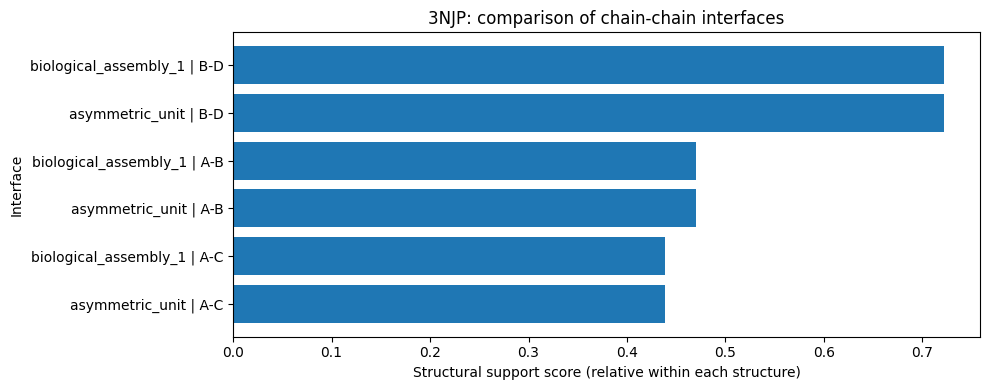

In [8]:

# Visual comparison
plot_df = ranked_interfaces.copy()
plot_df["label"] = plot_df["structure"] + " | " + plot_df["pair"]
plot_df = plot_df.sort_values("structural_support_score", ascending=True)

plt.figure(figsize=(10, max(4, 0.38 * len(plot_df))))
plt.barh(plot_df["label"], plot_df["structural_support_score"])
plt.xlabel("Structural support score (relative within each structure)")
plt.ylabel("Interface")
plt.title(f"{PDB_ID}: comparison of chain-chain interfaces")
plt.tight_layout()
plt.show()



## 6. Check whether B–D is present in the annotated biological assembly

Presence in the biological assembly is stronger evidence than a high contact count in the asymmetric unit alone.

The notebook separately asks:

- Is B–D present in the asymmetric unit?
- Is B–D present as an interface in biological assembly 1?
- What rank does B–D obtain?
- Is a competing interface substantially stronger?


In [9]:

def get_pair_row(df, structure_prefix, target_pair):
    pair_name = "-".join(sorted(target_pair))
    rows = df[
        df["structure"].str.startswith(structure_prefix)
        & (df["pair"] == pair_name)
    ]
    return None if rows.empty else rows.sort_values(
        "structural_support_score", ascending=False
    ).iloc[0]


target_asym = get_pair_row(ranked_interfaces, "asymmetric_unit", TARGET_PAIR)
target_assembly = get_pair_row(
    ranked_interfaces, f"biological_assembly_{ASSEMBLY_ID}", TARGET_PAIR
)

print("B–D in asymmetric unit:", target_asym is not None)
print("B–D in biological assembly:", target_assembly is not None)

if target_asym is not None:
    display(target_asym.to_frame("B-D asymmetric unit"))

if target_assembly is not None:
    display(target_assembly.to_frame("B-D biological assembly"))


B–D in asymmetric unit: True
B–D in biological assembly: True


,B-D asymmetric unit
structure,asymmetric_unit
chain_1,B
chain_2,D
pair,B-D
is_target_BD,True
heavy_atom_contacts,440
contacting_residue_pairs,88
interface_residues_chain_1,43
interface_residues_chain_2,31
interface_residues_total,74


,B-D biological assembly
structure,biological_assembly_1
chain_1,B
chain_2,D
pair,B-D
is_target_BD,True
heavy_atom_contacts,440
contacting_residue_pairs,88
interface_residues_chain_1,43
interface_residues_chain_2,31
interface_residues_total,74



## 7. Optional PDBePISA retrieval

This cell attempts to retrieve precomputed PISA interface information from the official PDBe service.

Because external schemas and chain naming can vary, PISA is treated as an **independent supporting source**, not silently merged into the structural score. The raw response is saved for inspection.


In [10]:

from xml.etree import ElementTree as ET

PISA_XML_PATH = OUTPUT_DIR / f"{PDB_ID}_pisa_interfaces.xml"
PISA_URL = f"https://www.ebi.ac.uk/pdbe/pisa/cgi-bin/interfaces.pisa?{PDB_ID.lower()}"

pisa_available = False
pisa_text = None

try:
    response = requests.get(PISA_URL, timeout=90)
    response.raise_for_status()
    pisa_text = response.text
    PISA_XML_PATH.write_text(pisa_text, encoding="utf-8")
    ET.fromstring(pisa_text)
    pisa_available = True
    print("PISA XML downloaded:", PISA_XML_PATH.resolve())
except Exception as exc:
    print("PISA retrieval was not available:", repr(exc))
    print("The rest of the notebook remains valid.")

print("PISA available:", pisa_available)


PISA XML downloaded: /Users/robertobruzzese/Desktop/venv/outputs/3NJP_pisa_interfaces.xml
PISA available: True


In [11]:

def flatten_xml_element(element, prefix=""):
    data = {}
    for child in list(element):
        key = f"{prefix}{child.tag}"
        if list(child):
            nested = flatten_xml_element(child, prefix=key + ".")
            data.update(nested)
        else:
            text = (child.text or "").strip()
            if text:
                if key in data:
                    data[key] = str(data[key]) + " | " + text
                else:
                    data[key] = text
    return data


pisa_interface_table = pd.DataFrame()

if pisa_available:
    root = ET.fromstring(pisa_text)
    candidate_elements = [
        element for element in root.iter()
        if element.tag.lower().endswith("interface")
    ]

    flattened = [flatten_xml_element(el) for el in candidate_elements]
    flattened = [row for row in flattened if row]

    if flattened:
        pisa_interface_table = pd.DataFrame(flattened)
        pisa_interface_table.to_csv(
            OUTPUT_DIR / f"{PDB_ID}_pisa_interfaces_flattened.csv",
            index=False
        )
        print("Parsed candidate PISA interface records:", len(pisa_interface_table))
        display(pisa_interface_table.head(20))
        print("Columns:")
        print("\n".join(map(str, pisa_interface_table.columns)))
    else:
        print("XML downloaded, but no interface elements were parsed automatically.")
else:
    print("Skipping PISA parsing.")


Parsed candidate PISA interface records: 39


,id,type,n_occ,int_area,int_solv_en,pvalue,stab_en,css,overlap,x-rel,...,molecule.residues.residue.bonds,cov-bonds.bond.chain-1,cov-bonds.bond.res-1,cov-bonds.bond.seqnum-1,cov-bonds.bond.atname-1,cov-bonds.bond.chain-2,cov-bonds.bond.res-2,cov-bonds.bond.seqnum-2,cov-bonds.bond.atname-2,cov-bonds.bond.dist
0,1,1,2,1633.0815432,-12.555343691,0.28161982366,-21.142077419,0.6407122016,No,No,...,HS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,2,1537.4656147,-15.742895198,0.2839546193,-23.00356314,1,No,No,...,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2,2,1509.2527078,-14.80714927,0.32615841212,-22.955891539,1,No,No,...,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,3,2,529.97368817,-0.62323057504,0.65679535677,-2.9934440149,0,No,Yes,...,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,4,2,351.12296325,4.7327125976,0.86113237935,3.394555403,0,No,No,...,HS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,5,1,341.79502826,1.6095628871,0.79159938292,-0.16658576673,0,No,No,...,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,6,2,248.0657182,-1.371334851,0.48952718594,-2.7034463414,0,No,Yes,...,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,7,2,228.12940443,4.9627625232,0.42474148804,2.7425767059,0,No,No,...,H,B,NAG,1328,C1,B,ASN,328,ND2,1.4392921872
8,9,8,2,227.44395335,4.9830153808,0.44999699957,2.7628295635,0,No,No,...,H,A,NAG,1328,C1,A,ASN,328,ND2,1.4383591346
9,10,9,2,212.90350167,-2.3961280814,0.49949984878,-2.8401652449,0,No,No,...,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns:
id
type
n_occ
int_area
int_solv_en
pvalue
stab_en
css
overlap
x-rel
fixed
h-bonds.n_bonds
h-bonds.bond.chain-1
h-bonds.bond.res-1
h-bonds.bond.seqnum-1
h-bonds.bond.atname-1
h-bonds.bond.chain-2
h-bonds.bond.res-2
h-bonds.bond.seqnum-2
h-bonds.bond.atname-2
h-bonds.bond.dist
salt-bridges.n_bonds
salt-bridges.bond.chain-1
salt-bridges.bond.res-1
salt-bridges.bond.seqnum-1
salt-bridges.bond.atname-1
salt-bridges.bond.chain-2
salt-bridges.bond.res-2
salt-bridges.bond.seqnum-2
salt-bridges.bond.atname-2
salt-bridges.bond.dist
ss-bonds.n_bonds
cov-bonds.n_bonds
molecule.id
molecule.chain_id
molecule.class
molecule.symop_no
molecule.symop
molecule.cell_i
molecule.cell_j
molecule.cell_k
molecule.rxx
molecule.rxy
molecule.rxz
molecule.tx
molecule.ryx
molecule.ryy
molecule.ryz
molecule.ty
molecule.rzx
molecule.rzy
molecule.rzz
molecule.tz
molecule.int_natoms
molecule.int_nres
molecule.int_area
molecule.int_solv_en
molecule.pvalue
molecule.residues.residue.ser_no
molecule.residues.resid


## 8. Transparent decision logic

The verdict is intentionally conservative.

### Strong positive evidence

- B–D occurs in the annotated biological assembly;
- B–D ranks first or close to first;
- B–D has substantial buried surface area and many residue contacts;
- no competing interface clearly dominates it.

### Negative evidence

- B–D is absent from the annotated assembly;
- another interface has a much higher score;
- B–D is only a weak crystal contact;
- descriptors are too small to support a stable protein-protein interface.


In [12]:

def build_verdict(ranked_df, target_pair):
    pair_name = "-".join(sorted(target_pair))
    assembly_name = f"biological_assembly_{ASSEMBLY_ID}"

    asym_df = ranked_df[ranked_df["structure"] == "asymmetric_unit"].copy()
    assembly_df = ranked_df[ranked_df["structure"] == assembly_name].copy()

    target_asym_df = asym_df[asym_df["pair"] == pair_name]
    target_assembly_df = assembly_df[assembly_df["pair"] == pair_name]

    evidence = []
    positive_points = 0
    negative_points = 0

    if not target_asym_df.empty:
        r = target_asym_df.iloc[0]
        evidence.append(
            f"{pair_name} is present in the asymmetric unit "
            f"(rank {int(r['rank_within_structure'])}, "
            f"BSA {r['buried_surface_area_A2']:.1f} Å², "
            f"{int(r['contacting_residue_pairs'])} contacting residue pairs)."
        )
        positive_points += 1
    else:
        evidence.append(f"{pair_name} is not detected as an asymmetric-unit interface.")
        negative_points += 2

    if not target_assembly_df.empty:
        r = target_assembly_df.iloc[0]
        evidence.append(
            f"{pair_name} is reproduced in annotated biological assembly {ASSEMBLY_ID} "
            f"with rank {int(r['rank_within_structure'])}."
        )
        positive_points += 4

        if int(r["rank_within_structure"]) == 1:
            evidence.append(f"{pair_name} is the top-ranked interface in the assembly.")
            positive_points += 2
        elif int(r["rank_within_structure"]) <= 2:
            evidence.append(f"{pair_name} is among the two strongest assembly interfaces.")
            positive_points += 1

        if r["buried_surface_area_A2"] >= 1200:
            evidence.append("Its buried surface area is large for a protein-protein interface.")
            positive_points += 2
        elif r["buried_surface_area_A2"] >= 700:
            evidence.append("Its buried surface area is moderate.")
            positive_points += 1
        else:
            evidence.append("Its buried surface area is relatively small.")
            negative_points += 1

        best = assembly_df.sort_values(
            "structural_support_score", ascending=False
        ).iloc[0]

        score_ratio = (
            float(r["structural_support_score"])
            / max(float(best["structural_support_score"]), 1e-9)
        )

        if best["pair"] != pair_name and score_ratio < 0.75:
            evidence.append(
                f"A competing assembly interface ({best['pair']}) has a substantially "
                "higher structural score."
            )
            negative_points += 3
        elif best["pair"] != pair_name:
            evidence.append(
                f"A competing interface ({best['pair']}) is ranked above B–D, "
                "but the scores are comparable."
            )
            negative_points += 1
    else:
        evidence.append(
            f"{pair_name} is not detected in annotated biological assembly {ASSEMBLY_ID}."
        )
        negative_points += 5

    # Conservative verdict
    if positive_points >= 7 and negative_points <= 1:
        verdict = "SUPPORTED"
        interpretation = (
            "The B–D choice is supported as the most plausible interface under the "
            "current structural criteria."
        )
    elif positive_points >= 4 and negative_points <= 3:
        verdict = "PLAUSIBLE BUT NOT UNIQUE"
        interpretation = (
            "B–D is biologically plausible, but the structural evidence does not make "
            "it uniquely preferable to all alternatives."
        )
    elif negative_points >= 5:
        verdict = "NOT SUPPORTED"
        interpretation = (
            "The current structural and assembly evidence does not support retaining "
            "B–D without revising the chain-pair choice."
        )
    else:
        verdict = "INCONCLUSIVE"
        interpretation = (
            "The available evidence is insufficient or conflicting; PISA/EPPIC, "
            "literature and/or experimental evidence should be added."
        )

    return {
        "pdb_id": PDB_ID,
        "target_pair": pair_name,
        "assembly_id": ASSEMBLY_ID,
        "verdict": verdict,
        "interpretation": interpretation,
        "positive_points": positive_points,
        "negative_points": negative_points,
        "evidence": evidence,
        "pisa_downloaded": pisa_available,
    }


validation = build_verdict(ranked_interfaces, TARGET_PAIR)

print("=" * 72)
print("FINAL COMPUTATIONAL VERDICT:", validation["verdict"])
print(validation["interpretation"])
print("=" * 72)
for item in validation["evidence"]:
    print("•", item)


FINAL COMPUTATIONAL VERDICT: SUPPORTED
The B–D choice is supported as the most plausible interface under the current structural criteria.
• B-D is present in the asymmetric unit (rank 1, BSA 3057.2 Å², 88 contacting residue pairs).
• B-D is reproduced in annotated biological assembly 1 with rank 1.
• B-D is the top-ranked interface in the assembly.
• Its buried surface area is large for a protein-protein interface.


## 9. Export the validation report

In [13]:

report_path = OUTPUT_DIR / "biological_interface_validation_report.md"
json_path = OUTPUT_DIR / "biological_interface_validation_report.json"

target_pair_name = validation["target_pair"]

report_lines = [
    "# Biological interface validation report",
    "",
    "## Input",
    f"- PDB ID: `{PDB_ID}`",
    f"- Target chain pair: `{target_pair_name}`",
    f"- Biological assembly analysed: `{ASSEMBLY_ID}`",
    f"- Asymmetric-unit file: `{ASYM_PATH}`",
    f"- Biological-assembly file: `{ASSEMBLY_PATH}`",
    "",
    "## Final computational verdict",
    f"**{validation['verdict']}**",
    "",
    validation["interpretation"],
    "",
    "## Evidence",
]

report_lines.extend([f"- {item}" for item in validation["evidence"]])

report_lines.extend([
    "",
    "## Important limitation",
    (
        "This verdict is a computational structural assessment. It does not establish "
        "the biological dimer with experimental certainty. Literature evidence, PISA/EPPIC "
        "classification, mutagenesis, binding measurements or oligomerisation experiments "
        "may still be required."
    ),
    "",
    "## Generated files",
    "- `biological_interface_comparison.csv`",
    f"- `{PDB_ID}_pisa_interfaces.xml` (when available)",
    f"- `{PDB_ID}_pisa_interfaces_flattened.csv` (when parsing succeeds)",
])

report_path.write_text("\n".join(report_lines), encoding="utf-8")
json_path.write_text(json.dumps(validation, indent=2), encoding="utf-8")

print("Saved:", report_path)
print(report_path.read_text(encoding="utf-8"))


Saved: outputs/biological_interface_validation_report.md
# Biological interface validation report

## Input
- PDB ID: `3NJP`
- Target chain pair: `B-D`
- Biological assembly analysed: `1`
- Asymmetric-unit file: `outputs/3NJP.pdb`
- Biological-assembly file: `outputs/3NJP-assembly1.cif`

## Final computational verdict
**SUPPORTED**

The B–D choice is supported as the most plausible interface under the current structural criteria.

## Evidence
- B-D is present in the asymmetric unit (rank 1, BSA 3057.2 Å², 88 contacting residue pairs).
- B-D is reproduced in annotated biological assembly 1 with rank 1.
- B-D is the top-ranked interface in the assembly.
- Its buried surface area is large for a protein-protein interface.

## Important limitation
This verdict is a computational structural assessment. It does not establish the biological dimer with experimental certainty. Literature evidence, PISA/EPPIC classification, mutagenesis, binding measurements or oligomerisation experiments may sti


## 10. Manual biological evidence checklist

Before describing B–D as biologically validated, complete these checks:

- [ ] B–D is present in the deposited biological assembly.
- [ ] PDBePISA classifies the corresponding interface as biologically relevant.
- [ ] EPPIC supports the same interface.
- [ ] The original 3NJP publication describes a compatible dimer/interaction.
- [ ] B–D interface residues overlap known functional or mutational residues.
- [ ] The interface is conserved in relevant homologues.
- [ ] If required, molecular dynamics shows persistence of the interface.
- [ ] Experimental evidence supports oligomerisation or interface disruption.

### Recommended language for the report

When the notebook returns `SUPPORTED`:

> Chains B and D were initially selected based on inter-chain contact density.  
> The choice was subsequently supported by analysis of the annotated biological
> assembly, buried surface area and physicochemical interface descriptors.
> B–D is therefore retained as the most plausible biological interface, while
> acknowledging that definitive validation would require independent biological
> or experimental evidence.

When it returns anything else, do not present B–D as confirmed.
